<a href="https://colab.research.google.com/github/AbdelazizElSayedDeveloper15/My-Projects_2026/blob/main/Sales_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- Which category and sub-category drive the most sales?
- Which region underperforms?
- How did sales change from 2015 to 2018, and is there a seasonal pattern?
- Which customer segment brings the most revenue?

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv ("/content/train.csv", encoding = "latin-1")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [4]:
df.isnull() .sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [5]:
df.drop_duplicates()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760


In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

**Data Cleaning Phase:**
- Imported the libraries
- Displayed and inspected the data
- Checked for null values and handled the 11 missing postal codes (Burlington, VT) by filling them with the correct ZIP code
- Checked for duplicate rows (result: [state your real result])
- Fixed the date column formatting (dayfirst=True)

In [7]:
df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

,Sales
Category,
Technology,827455.8730
Furniture,728658.5757
Office Supplies,705422.3340


We represent the most sold catergory and sales amount

In [8]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)
df["Year"] = df["Order Date"].dt.year
df["Postal Code"] = df["Postal Code"].fillna(5401)   # Burlington, VT, the only city with missing codes

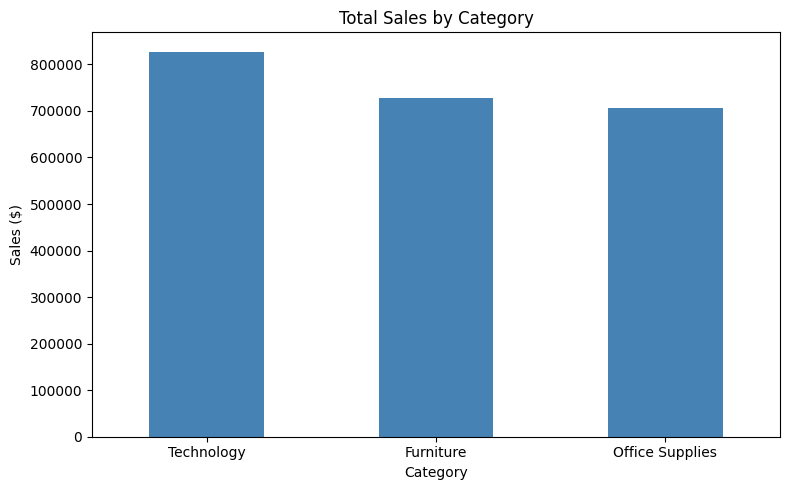

In [9]:
by_cat = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
by_cat.plot(kind="bar", color="steelblue")
plt.title("Total Sales by Category")
plt.ylabel("Sales ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("chart1_category.png", dpi=150)
plt.show()

Technology is the top-selling category, at roughly $827,000 in total sales.

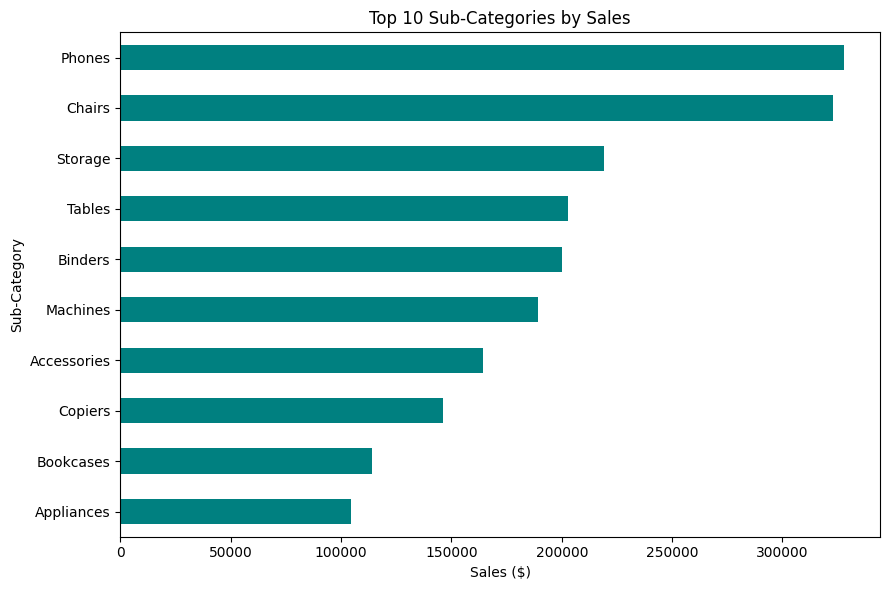

In [10]:
top_sub = df.groupby("Sub-Category")["Sales"].sum().sort_values().tail(10)

plt.figure(figsize=(9, 6))
top_sub.plot(kind="barh", color="teal")
plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Sales ($)")
plt.tight_layout()
plt.savefig("chart2_subcategory.png", dpi=150)
plt.show()

Phones is the top-selling sub-category, at roughly $327,800.

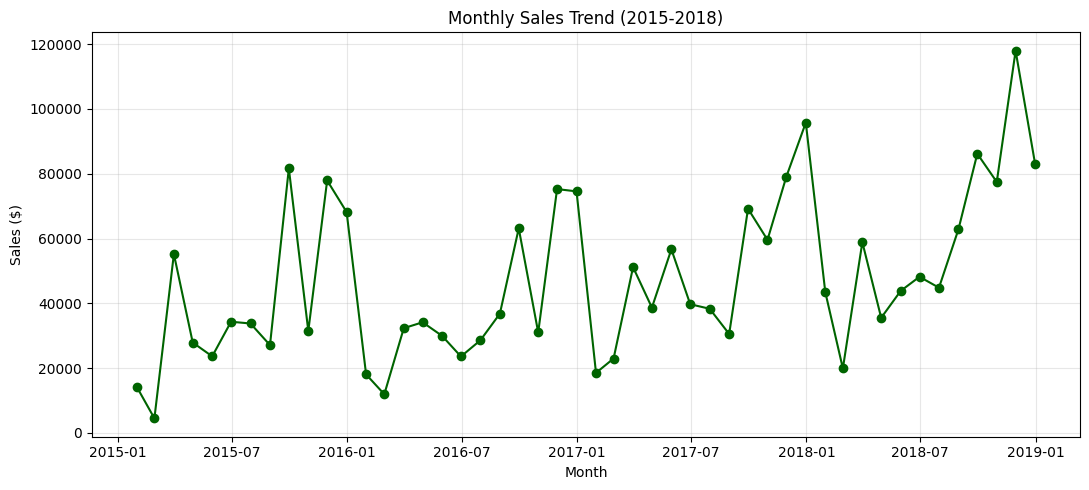

In [11]:
monthly = df.set_index("Order Date")["Sales"].resample("ME").sum()

plt.figure(figsize=(11, 5))
plt.plot(monthly.index, monthly.values, marker="o", color="darkgreen")
plt.title("Monthly Sales Trend (2015-2018)")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("chart3_monthly.png", dpi=150)
plt.show()

Monthly sales peaked in November 2018, at close to $118,000, with a rising trend across 2015-2018.

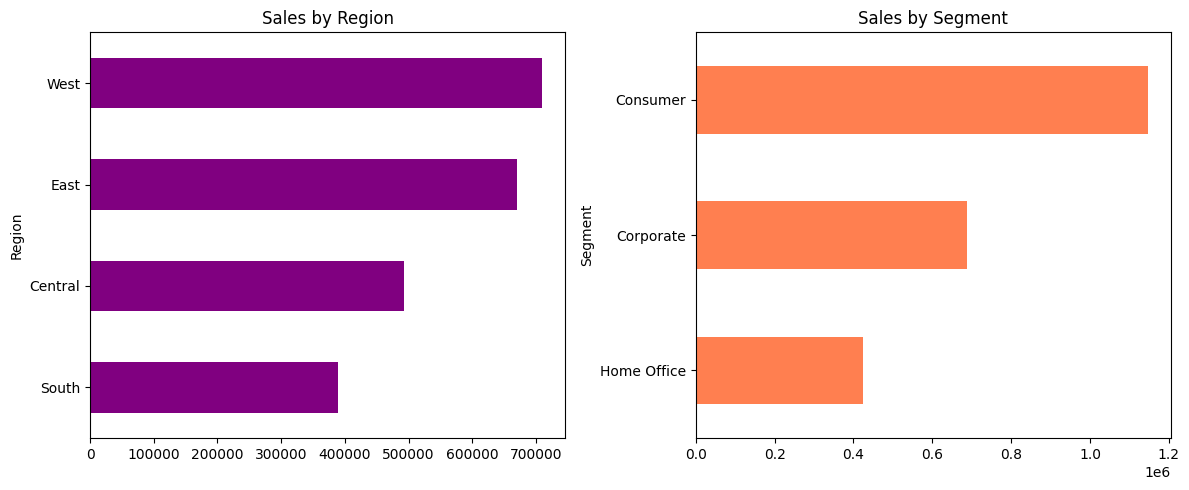

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
df.groupby("Region")["Sales"].sum().sort_values().plot(kind="barh", ax=ax[0], color="purple")
ax[0].set_title("Sales by Region")
df.groupby("Segment")["Sales"].sum().sort_values().plot(kind="barh", ax=ax[1], color="coral")
ax[1].set_title("Sales by Segment")
plt.tight_layout()
plt.savefig("chart4_region_segment.png", dpi=150)
plt.show()

The West region leads in sales at roughly $710,200,
the Consumer segment leads at roughly $1,148,000.

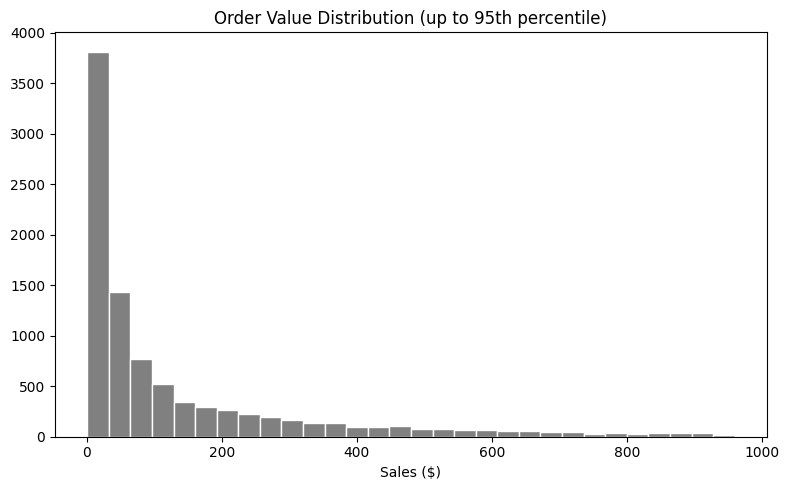

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(df[df["Sales"] <= df["Sales"].quantile(0.95)]["Sales"], bins=30, color="gray", edgecolor="white")
plt.title("Order Value Distribution (up to 95th percentile)")
plt.xlabel("Sales ($)")
plt.tight_layout()
plt.savefig("chart5_distribution.png", dpi=150)
plt.show()

Most orders are low-value — the first bin (under about $35) holds close to 3,800 orders, showing the majority of purchases are small.